In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

print("✓ Core libraries loaded.")

✓ Core libraries loaded.


In [2]:
#Data Merging And Cleaning
df_anti = pd.read_csv('items for antidepressant drugs per.csv')
df_anx = pd.read_csv('items for anxiolytics per.csv')

df_anti['Category'] = 'Antidepressants'
df_anx['Category'] = 'Anxiolytics'

df_rx = pd.concat([df_anti, df_anx], ignore_index=True)

df_rx['Date'] = pd.to_datetime(df_rx['date'])
df_rx['Region'] = df_rx['name'].str.replace('NHS ', '', regex=False).str.title()

df_rx = df_rx.rename(columns={'y_items': 'Volume_Items', 'y_actual_cost': 'Cost_GBP'})

df_rx = df_rx[['Date', 'Region', 'Volume_Items', 'Cost_GBP', 'Category']]
df_rx = df_rx[df_rx['Volume_Items'] > 0]

print(f"✓ Master Dataset Created. Total valid rows: {len(df_rx)}")
df_rx.head()

✓ Master Dataset Created. Total valid rows: 12840


,Date,Region,Volume_Items,Cost_GBP,Category
1,2021-04-01,Frimley,4927,19060.68,Antidepressants
2,2021-04-01,West Lancashire,13688,44287.14,Antidepressants
3,2021-04-01,East Staffordshire,15906,50923.83,Antidepressants
4,2021-04-01,Cannock Chase,17061,57081.70,Antidepressants
5,2021-04-01,Southport And Formby,17479,62547.18,Antidepressants


In [3]:
#Monthly Trend Summary
monthly_summary = df_rx.groupby(['Date', 'Category'])[['Volume_Items', 'Cost_GBP']].sum().reset_index()
monthly_summary.to_csv('monthly_trend_summary.csv', index=False)

#Regional Summary (Aggregating all-time volume per CCG)
regional_summary = df_rx.groupby(['Region', 'Category'])[['Volume_Items', 'Cost_GBP']].sum().reset_index()
regional_summary.to_csv('regional_prescribing_summary.csv', index=False)

print("✓ Deliverables Completed: CSV Outputs exported successfully.")

✓ Deliverables Completed: CSV Outputs exported successfully.


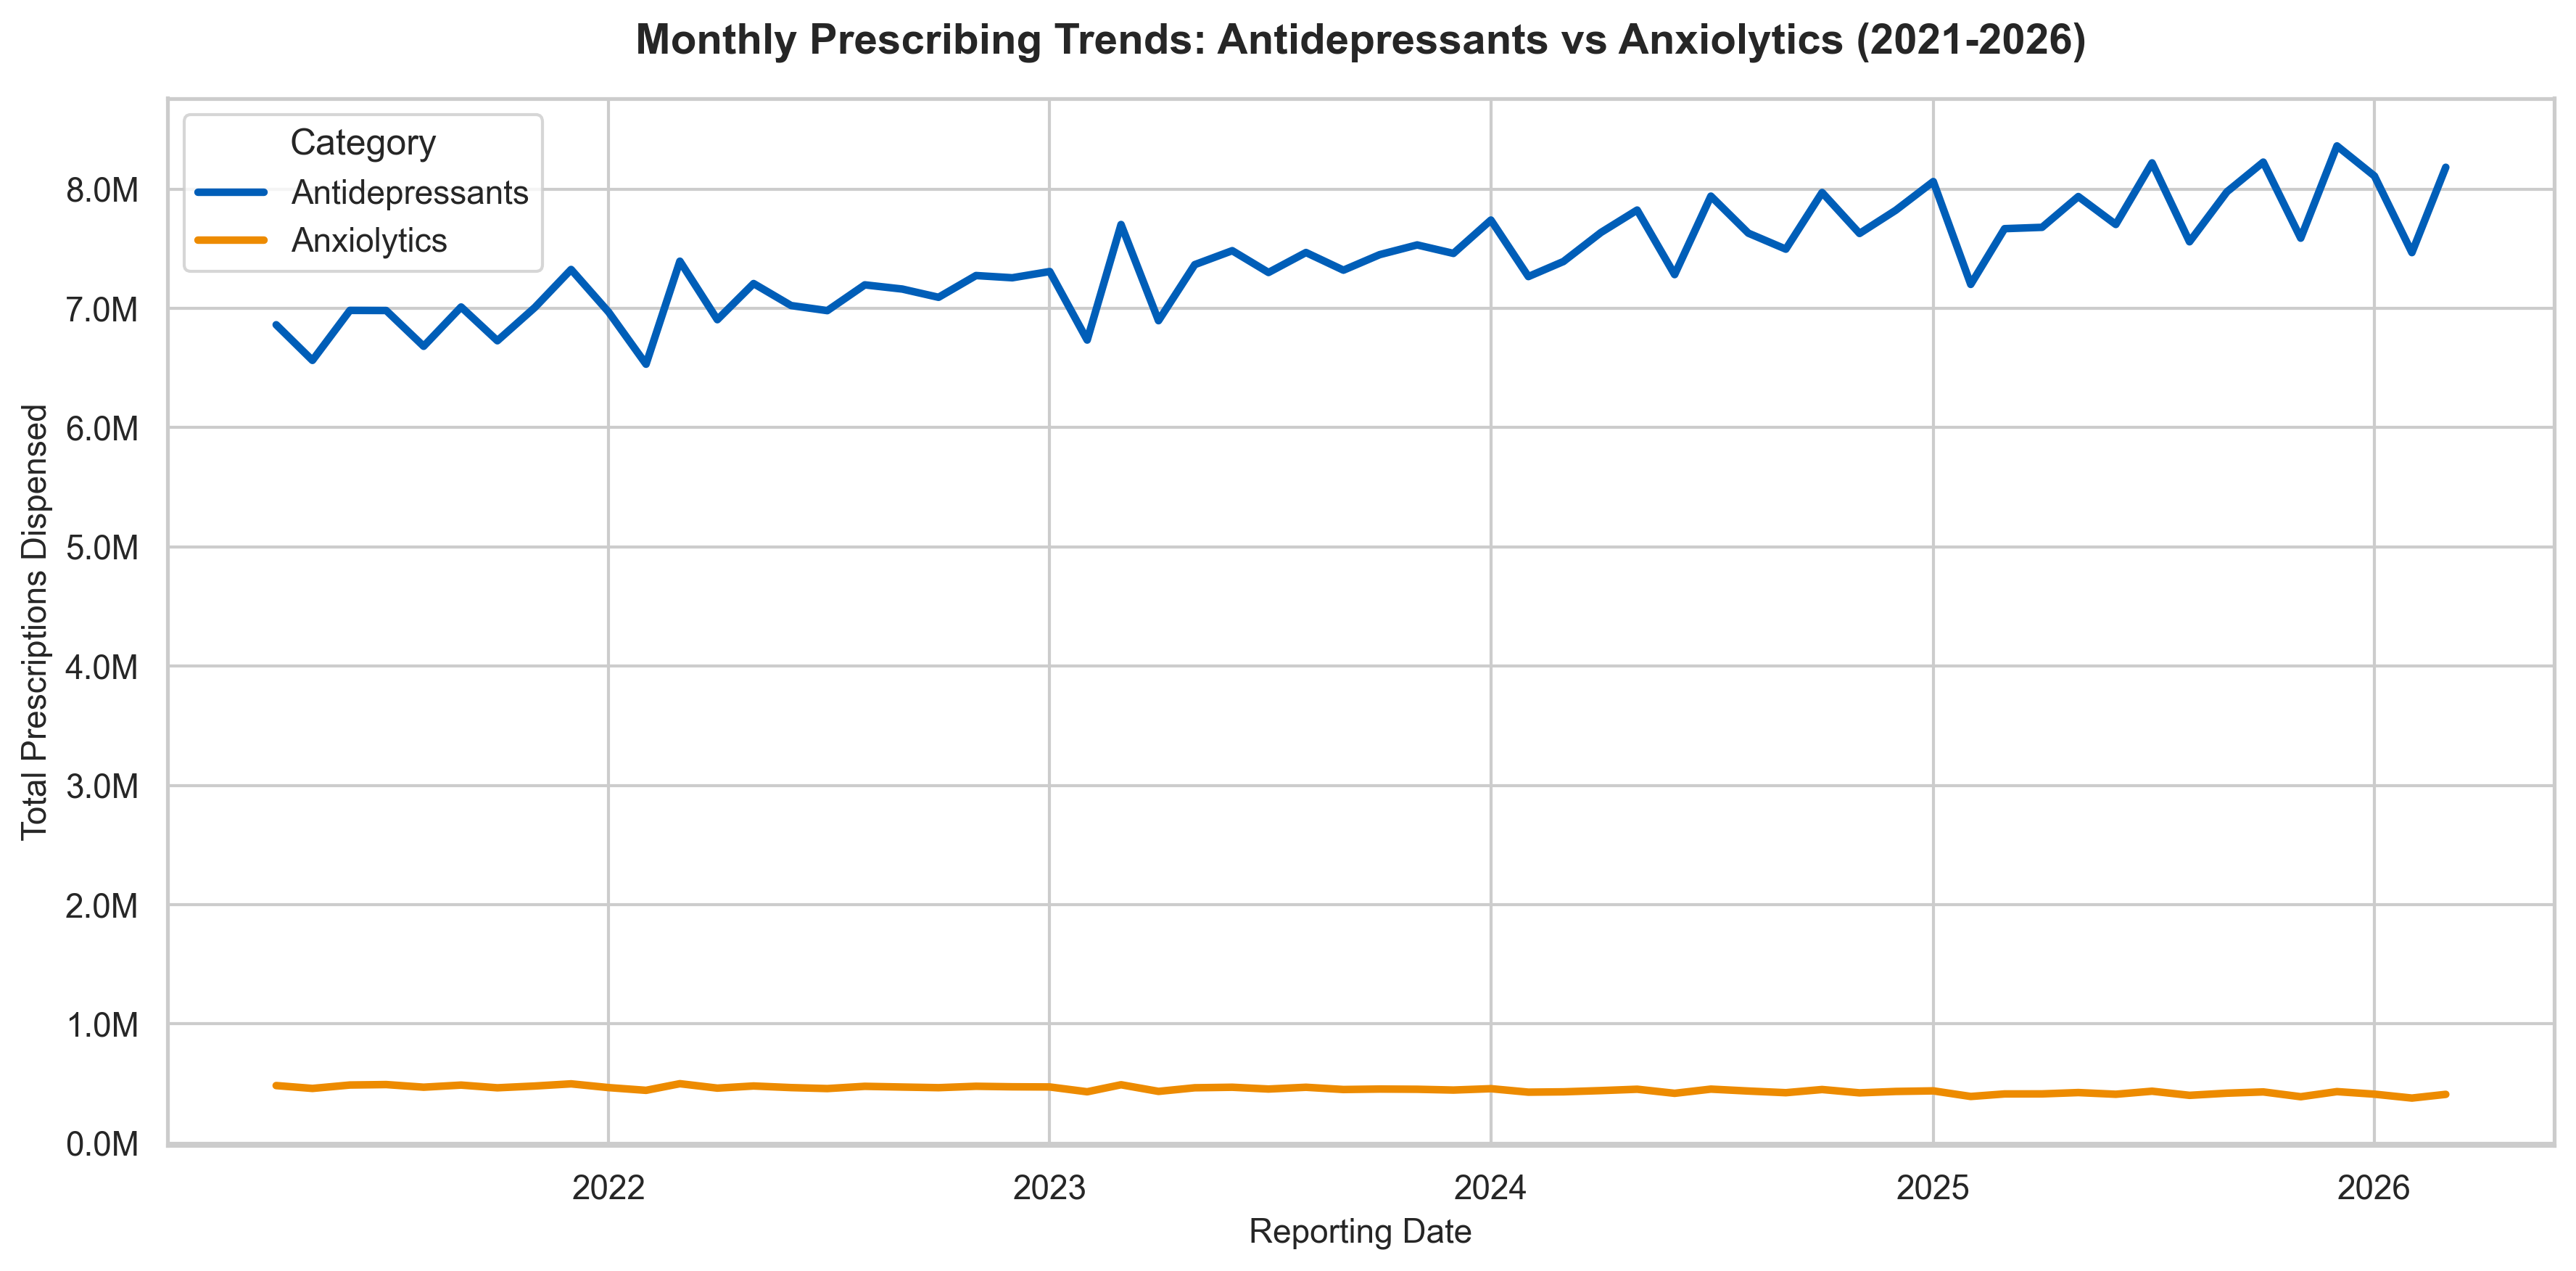

In [4]:
#Chart 1: Monthly Trends Line Chart
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_summary, 
    x='Date', 
    y='Volume_Items', 
    hue='Category', 
    palette=['#005EB8', '#ED8B00'], # NHS Blue & Orange
    linewidth=2.5
)

plt.title('Monthly Prescribing Trends: Antidepressants vs Anxiolytics (2021-2026)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Prescriptions Dispensed', fontsize=11)
plt.xlabel('Reporting Date', fontsize=11)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.savefig('chart1_monthly_trends.png')
plt.show()

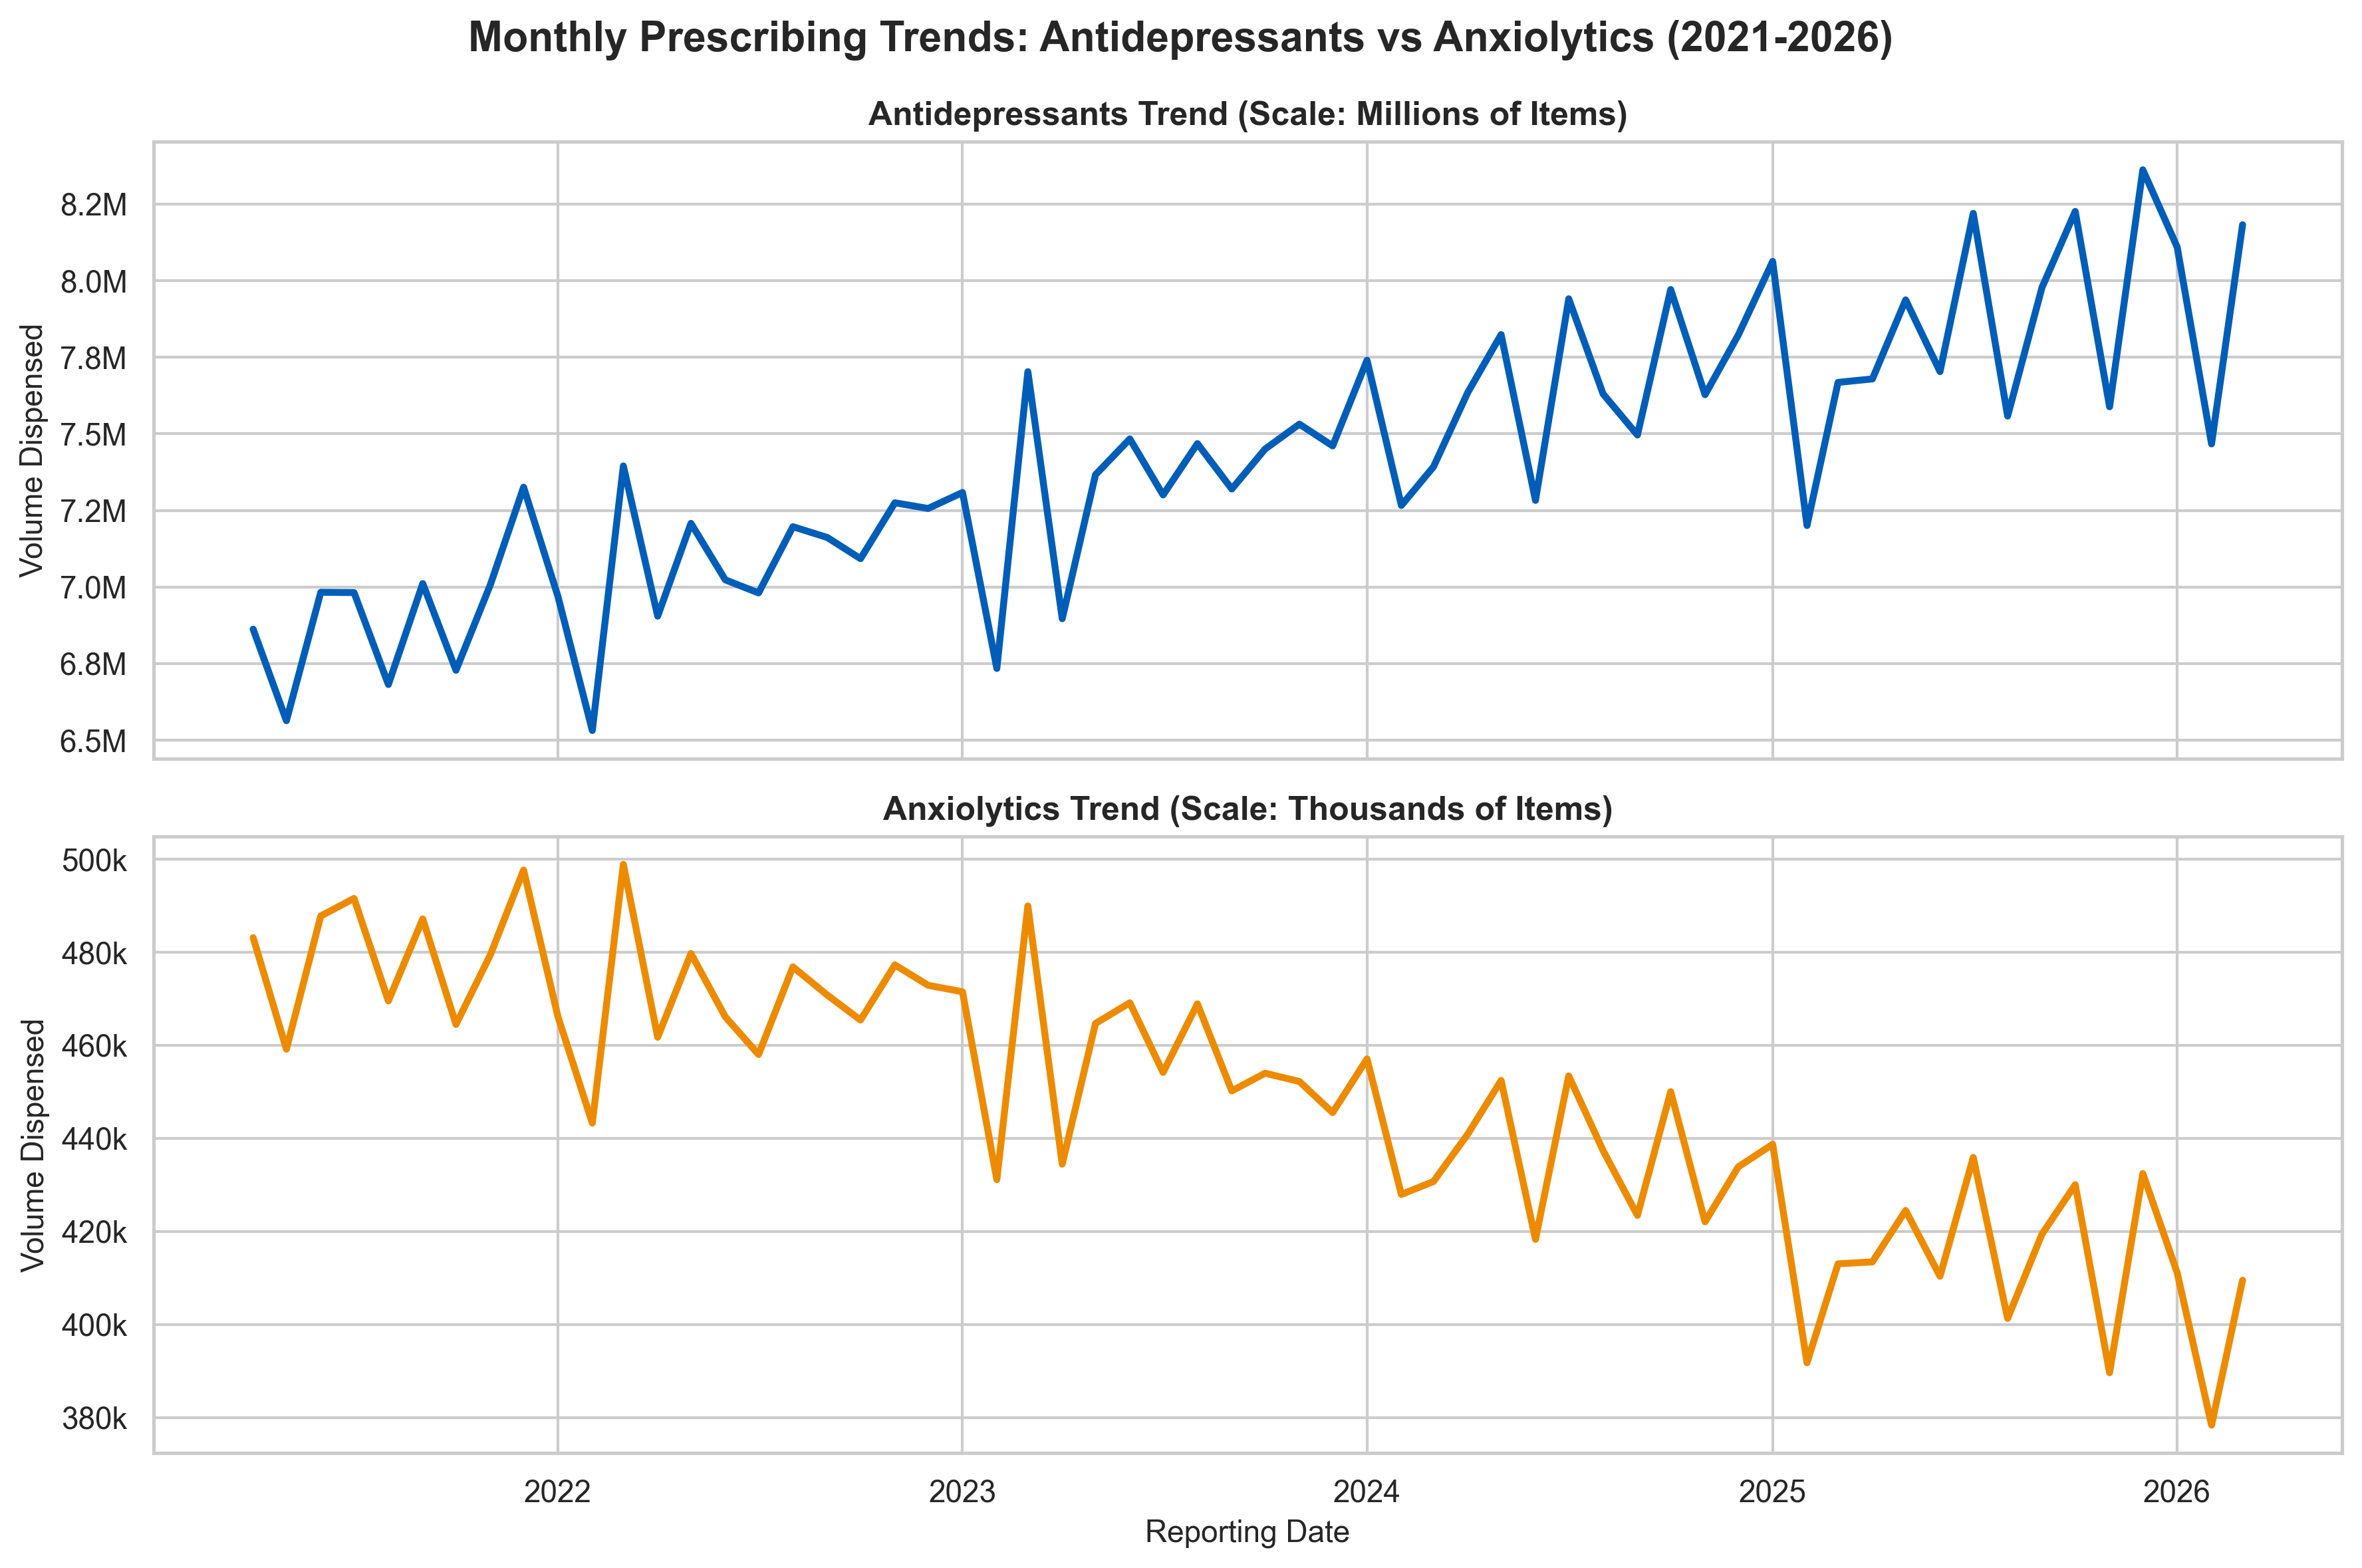

In [5]:
#Chart 1: Monthly Trends Line Chart (Scale-Adjusted Subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 1. Top Chart: Antidepressants
sns.lineplot(
    data=monthly_summary[monthly_summary['Category'] == 'Antidepressants'], 
    x='Date', y='Volume_Items', 
    color='#005EB8', linewidth=2.5, ax=ax1
)
ax1.set_title('Antidepressants Trend (Scale: Millions of Items)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Volume Dispensed', fontsize=11)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M"))

# 2. Bottom Chart: Anxiolytics
sns.lineplot(
    data=monthly_summary[monthly_summary['Category'] == 'Anxiolytics'], 
    x='Date', y='Volume_Items', 
    color='#ED8B00', linewidth=2.5, ax=ax2
)
ax2.set_title('Anxiolytics Trend (Scale: Thousands of Items)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Volume Dispensed', fontsize=11)
ax2.set_xlabel('Reporting Date', fontsize=11)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1e3:.0f}k"))

fig.suptitle('Monthly Prescribing Trends: Antidepressants vs Anxiolytics (2021-2026)', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('chart1_monthly_trends.png', dpi=300)
plt.show()

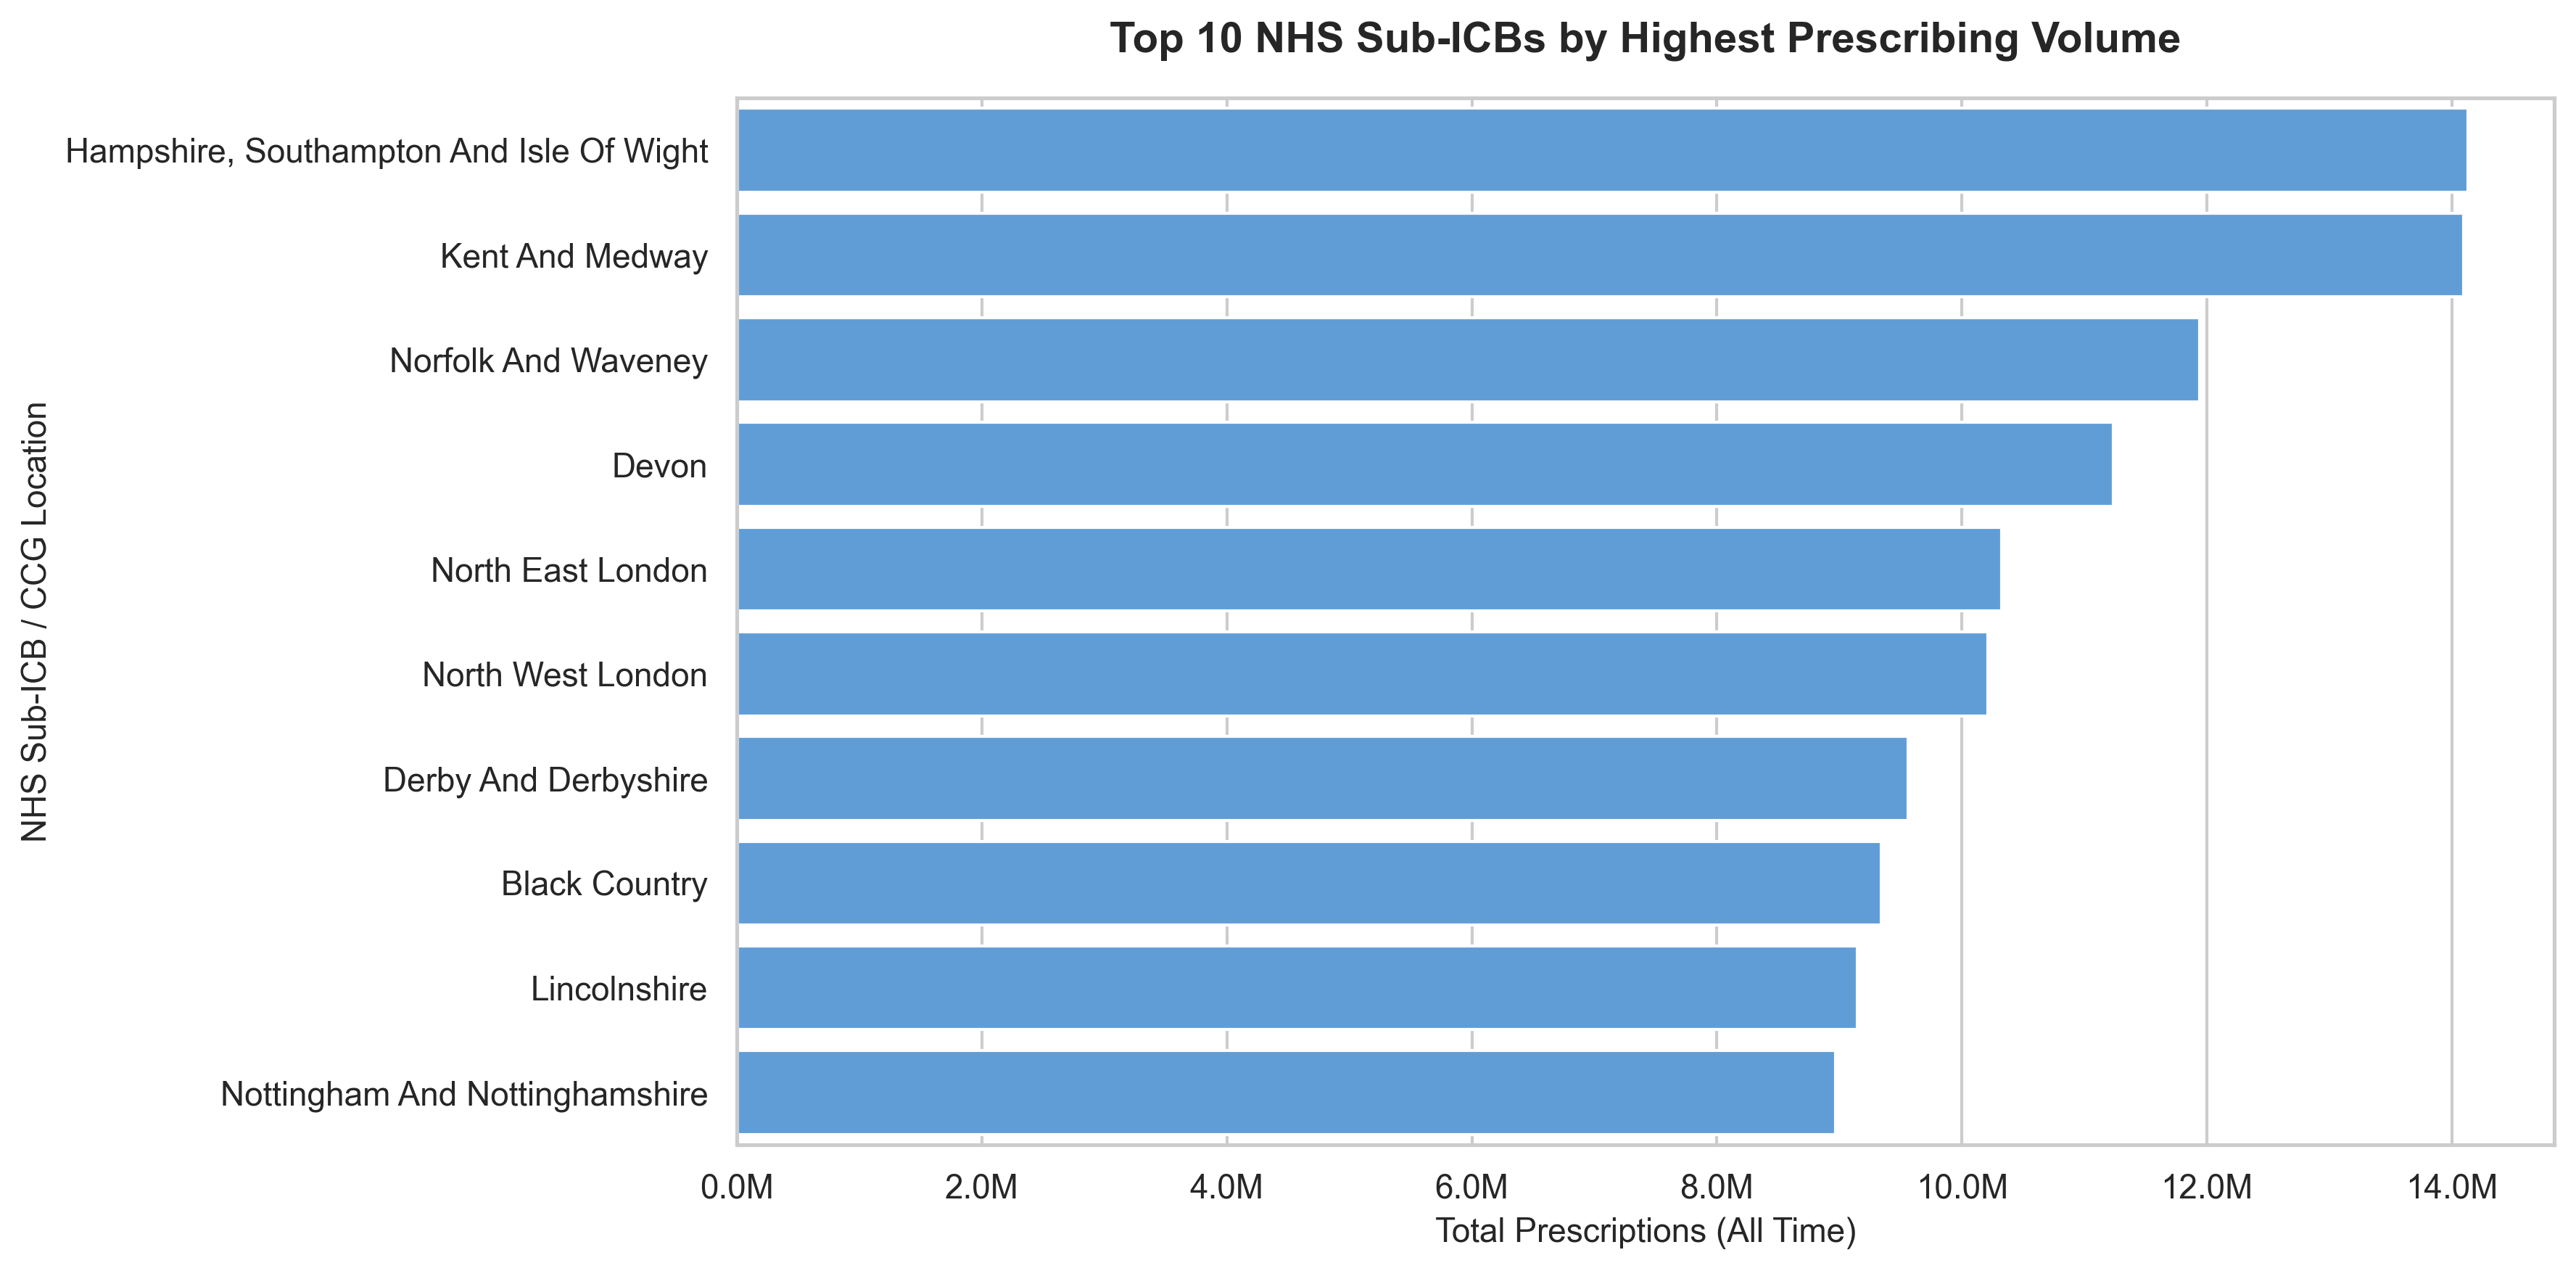

In [6]:
# Chart 2: Top 10 Regional Hotspots
top_regions = df_rx.groupby('Region')['Volume_Items'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_regions, x='Volume_Items', y='Region', color='#4C9EEB')

plt.title('Top 10 NHS Sub-ICBs by Highest Prescribing Volume', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Prescriptions (All Time)', fontsize=11)
plt.ylabel('NHS Sub-ICB / CCG Location', fontsize=11)

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.savefig('chart2_regional_top10.png')
plt.show()

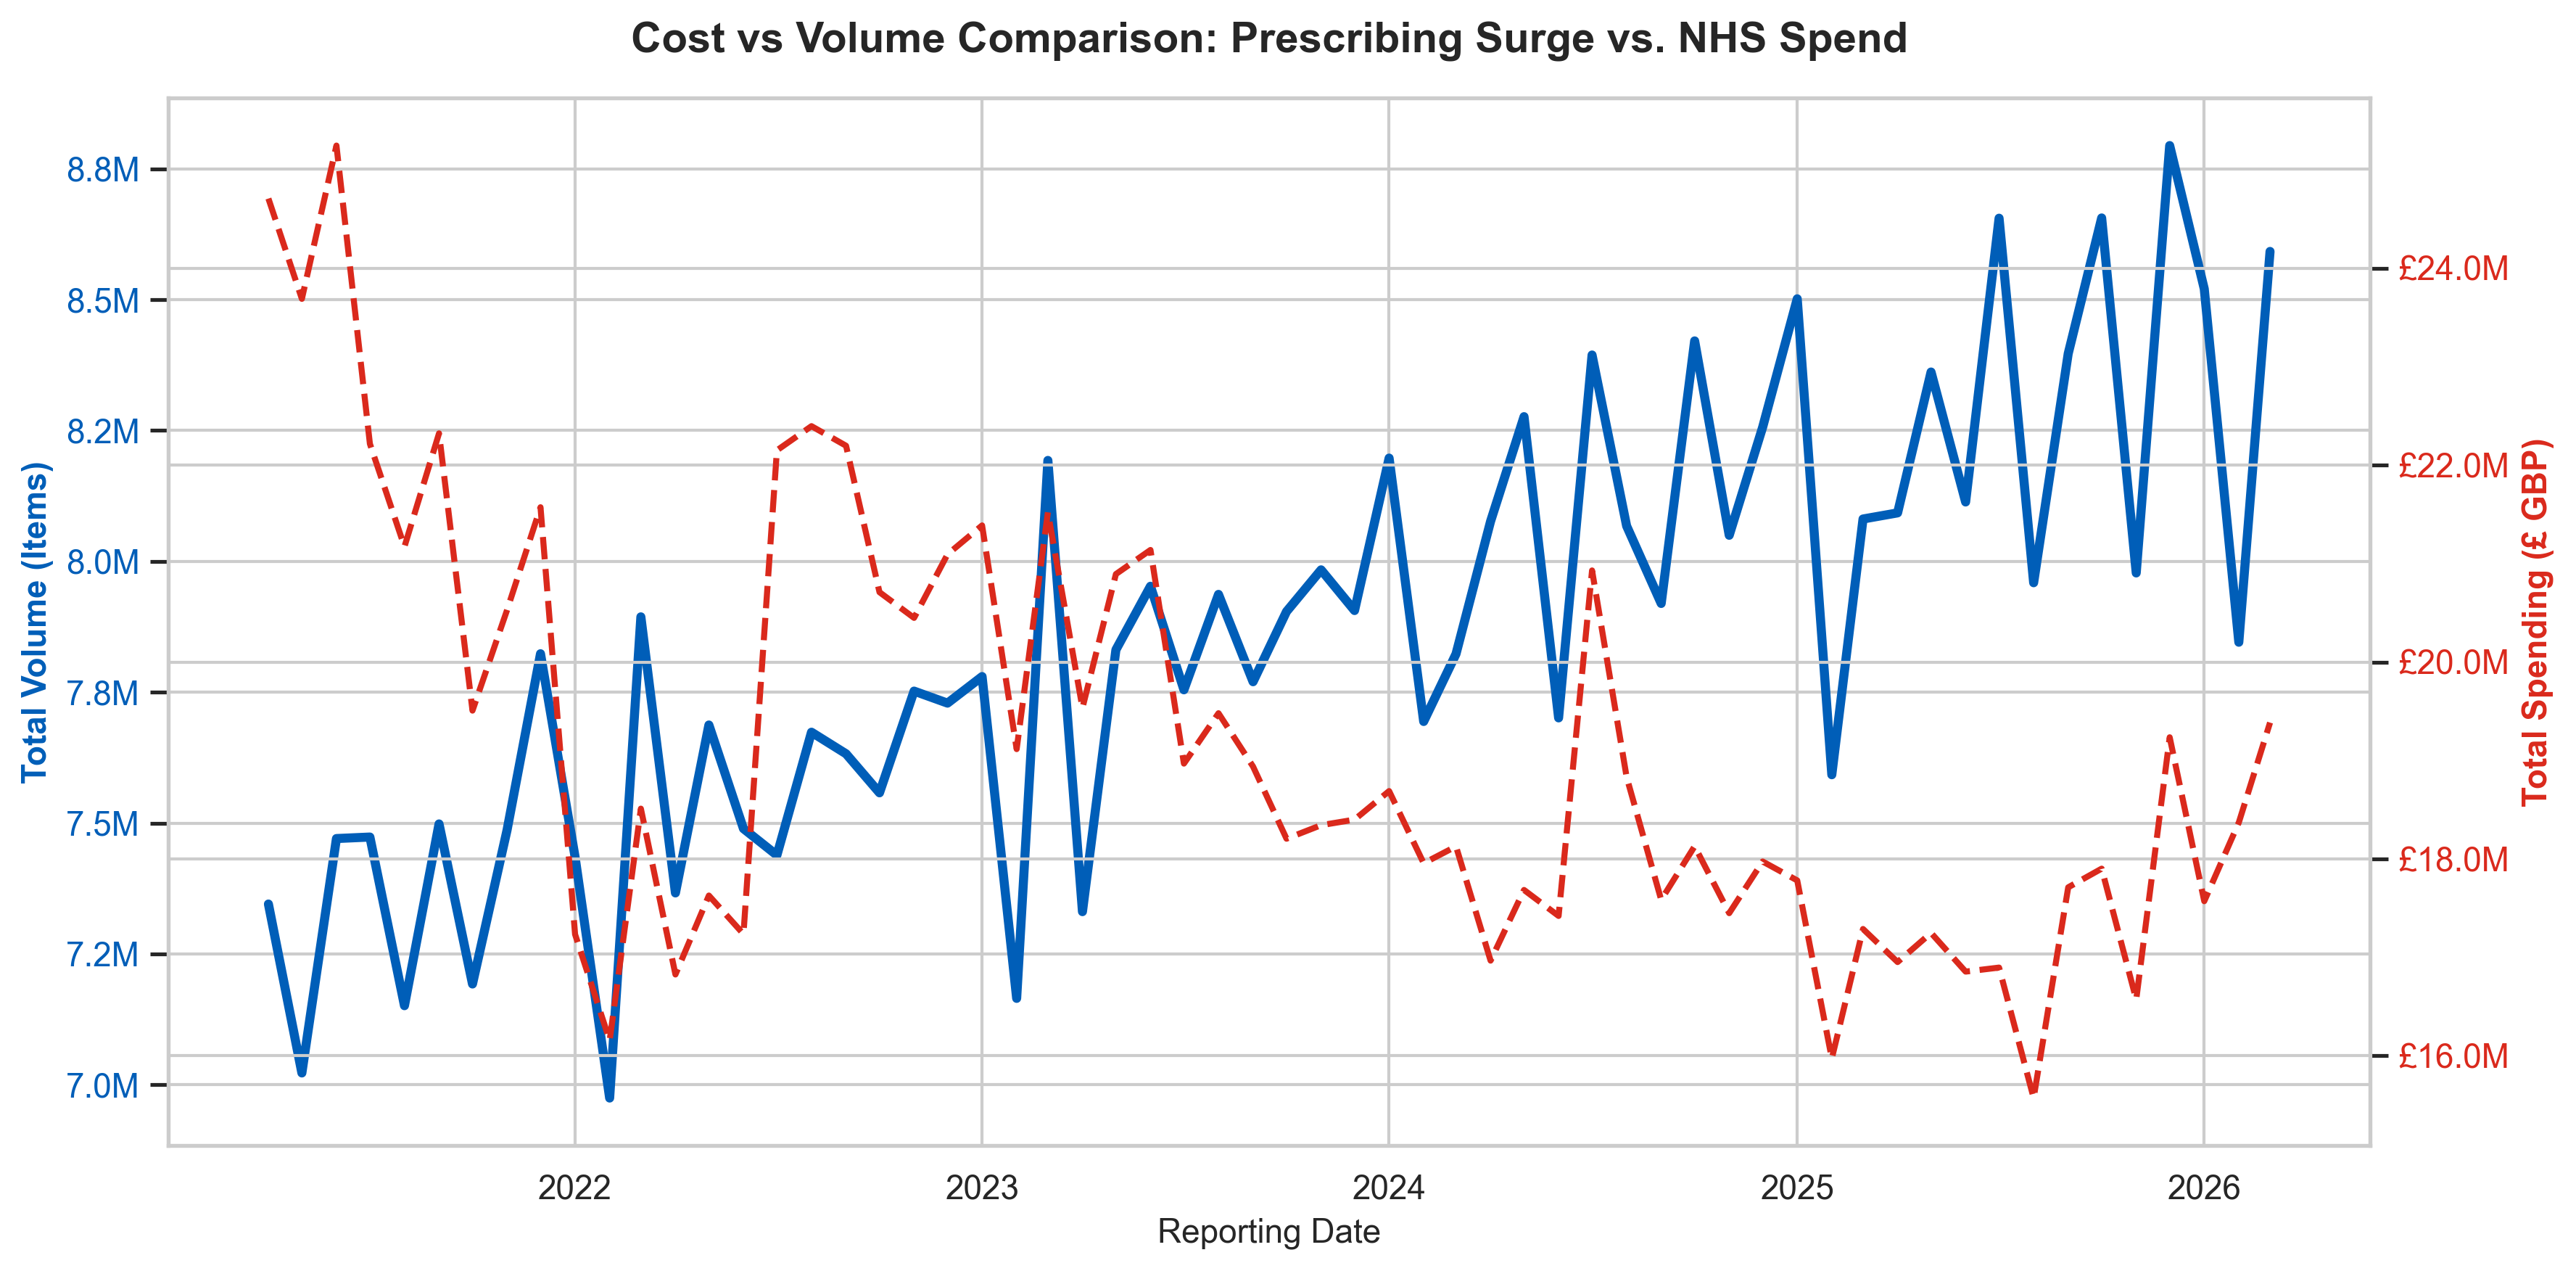

In [7]:
# Chart 3: Cost Vs Volume Trend Analysis
cost_vs_vol = df_rx.groupby('Date')[['Volume_Items', 'Cost_GBP']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = '#005EB8' # NHS Blue
ax1.set_xlabel('Reporting Date', fontsize=11)
ax1.set_ylabel('Total Volume (Items)', color=color1, fontweight='bold', fontsize=11)
ax1.plot(cost_vs_vol['Date'], cost_vs_vol['Volume_Items'], color=color1, linewidth=3, label='Prescription Volume')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M"))

ax2 = ax1.twinx()  
color2 = '#DA291C' # NHS Red
ax2.set_ylabel('Total Spending (£ GBP)', color=color2, fontweight='bold', fontsize=11)
ax2.plot(cost_vs_vol['Date'], cost_vs_vol['Cost_GBP'], color=color2, linewidth=2, linestyle='--', label='Actual Cost')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"£{x/1e6:.1f}M"))

plt.title('Cost vs Volume Comparison: Prescribing Surge vs. NHS Spend', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig('chart3_cost_vs_volume.png')
plt.show()